In [1]:
import gymnasium as gym
from stable_baselines3 import DQN, PPO

import numpy as np
import networkx as nx

In [2]:
from gymnasium import spaces

class QuiverMutationEnvironment(gym.Env):
    def __init__(self, quivers, random_max_steps, max_edges = None):
        self._quiver = quivers
        self._num_nodes = quivers.shape[0]
        self._max_edges = max_edges

        self._random_max_steps = random_max_steps

        self.action_space = spaces.Discrete(self._num_nodes)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(self._num_nodes**2 + 1,), dtype=np.float64)

        self._b_mat = None#np.eye((self._num_nodes, self._num_nodes), dtype=np.float32)
        self._prev_val = 0
        self._prev_action = -1

    @staticmethod
    def _mutate_mat(adjacency_mat, node):
        mask = np.zeros_like(adjacency_mat)
        mask[node, ...] = 1
        mask[..., node] = 1
        mask = mask > 0

        mat= mask*(-adjacency_mat) + (~mask)*(adjacency_mat + \
            (np.abs(adjacency_mat[..., node][..., np.newaxis])*adjacency_mat[node, ...][np.newaxis, ...] + \
            adjacency_mat[..., node][..., np.newaxis]*np.abs(adjacency_mat[node, ...][np.newaxis, ...]))/2)
        return np.round(mat)

    def _get_obs(self):
        # X = np.asarray([[i, -i] for i in range(self._b_mat.shape[0])], dtype=np.float32)
        # mat_feats = self._b_mat@X
        # feats = np.concatenate([self._b_mat.flatten(), mat_feats.flatten()], axis=0)
        feats = self._b_mat.flatten()
        return np.append(feats, [self._prev_action])

    def _get_info(self):
        return {"b_mat": self._b_mat.copy(order="F")}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self._prev_action = -1
        self._prev_val = 0
        actions = self.np_random.choice(self._num_nodes, size=(self._random_max_steps,))
        self._b_mat = self._quiver.copy(order="F")

        for a in actions:
            new_mat = self._mutate_mat(self._b_mat, a)
            if self._max_edges is not None:
                if np.abs(new_mat).sum() > 2*self._max_edges:
                    new_mat = self._b_mat
            self._b_mat = new_mat

        obs = self._get_obs()
        info = self._get_info()

        return obs, info

    def step(self, action):
        new_mat = self._mutate_mat(self._b_mat, action)
        if self._max_edges is not None:
            if np.abs(new_mat).sum() > 2*self._max_edges:
                new_mat = self._b_mat
        self._b_mat = new_mat
        state = self._b_mat.copy(order="F")

        state[state <= 0] = 0
        gr = nx.from_numpy_array(state, create_using=nx.MultiDiGraph())

        num_cycles = len([*nx.cycles.cycle_basis(gr)])
        reward = 20*(self._prev_val - num_cycles)
        self._prev_val = num_cycles

        if action == self._prev_action:
            reward -= 5
        self._prev_action = action

        terminated = (num_cycles == 0)
        if terminated:
            reward = 10

        obs = self._get_obs()
        info = self._get_info()
        return obs, reward, terminated, False, info

In [3]:
from stable_baselines3.common.env_checker import check_env

In [4]:
# quiver_adj = np.asarray([
#     [0,1,3,0,-2,3,0],
#     [-1,0,-1,0,2,0,0],
#     [-3,1,0,2,4,0,4],
#     [0,0,-2,0,1,-2,0],
#     [2,-2,-4,-1,0,-4,-2],
#     [-3,0,0,2,4,0,3],
#     [0,0,-4,0,2,-3,0]])

quiver_adj = np.asarray([[0,0,-1,-1,1,0,0],
    [0,0,0,0,1,0,0],
    [1,0,0,0,0,-1,0],
    [1,0,0,0,0,0,-1],
    [-1,-1,0,0,0,1,0],
    [0,0,1,0,-1,0,1],
    [0,0,0,1,0,-1,0]])

env = QuiverMutationEnvironment(quiver_adj, random_max_steps=20, max_edges = None)

In [5]:
check_env(env)

In [6]:
log_dir = "logs"
model = PPO("MlpPolicy", env, learning_rate=1e-3, verbose=1, tensorboard_log=log_dir)
model.learn(total_timesteps=100000, progress_bar=True, tb_log_name="quivers")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to logs/quivers_4


Output()

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 57.5     |
|    ep_rew_mean     | -61.4    |
| time/              |          |
|    fps             | 776      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------


-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 69.2          |
|    ep_rew_mean          | -70.3         |
| time/                   |               |
|    fps                  | 676           |
|    iterations           | 2             |
|    time_elapsed         | 6             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.013350871   |
|    clip_fraction        | 0.155         |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.94         |
|    explained_variance   | -0.0032393932 |
|    learning_rate        | 0.001         |
|    loss                 | 359           |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.0283       |
|    value_loss           | 852           |
-------------------------------------------


-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 64.7          |
|    ep_rew_mean          | -65.7         |
| time/                   |               |
|    fps                  | 656           |
|    iterations           | 3             |
|    time_elapsed         | 9             |
|    total_timesteps      | 6144          |
| train/                  |               |
|    approx_kl            | 0.012162406   |
|    clip_fraction        | 0.133         |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.92         |
|    explained_variance   | -0.0061352253 |
|    learning_rate        | 0.001         |
|    loss                 | 451           |
|    n_updates            | 20            |
|    policy_gradient_loss | -0.0273       |
|    value_loss           | 805           |
-------------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 20.8        |
|    ep_rew_mean          | -19.4       |
| time/                   |             |
|    fps                  | 631         |
|    iterations           | 45          |
|    time_elapsed         | 146         |
|    total_timesteps      | 92160       |
| train/                  |             |
|    approx_kl            | 0.016170364 |
|    clip_fraction        | 0.179       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.841      |
|    explained_variance   | 0.81682     |
|    learning_rate        | 0.001       |
|    loss                 | 61.8        |
|    n_updates            | 440         |
|    policy_gradient_loss | -0.0351     |
|    value_loss           | 114         |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 28.1        |
|    ep_rew_mean          | -20.6       |
| time/                   |             |
|    fps                  | 631         |
|    iterations           | 46          |
|    time_elapsed         | 149         |
|    total_timesteps      | 94208       |
| train/                  |             |
|    approx_kl            | 0.016323034 |
|    clip_fraction        | 0.154       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.793      |
|    explained_variance   | 0.79146886  |
|    learning_rate        | 0.001       |
|    loss                 | 33.4        |
|    n_updates            | 450         |
|    policy_gradient_loss | -0.0336     |
|    value_loss           | 107         |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 21.6        |
|    ep_rew_mean          | -18.6       |
| time/                   |             |
|    fps                  | 630         |
|    iterations           | 47          |
|    time_elapsed         | 152         |
|    total_timesteps      | 96256       |
| train/                  |             |
|    approx_kl            | 0.015633725 |
|    clip_fraction        | 0.156       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.7        |
|    explained_variance   | 0.75821424  |
|    learning_rate        | 0.001       |
|    loss                 | 42.8        |
|    n_updates            | 460         |
|    policy_gradient_loss | -0.0352     |
|    value_loss           | 97.9        |
-----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 21.5       |
|    ep_rew_mean          | -17.6      |
| time/                   |            |
|    fps                  | 630        |
|    iterations           | 48         |
|    time_elapsed         | 155        |
|    total_timesteps      | 98304      |
| train/                  |            |
|    approx_kl            | 0.01609334 |
|    clip_fraction        | 0.158      |
|    clip_range           | 0.2        |
|    entropy_loss         | -0.807     |
|    explained_variance   | 0.8278427  |
|    learning_rate        | 0.001      |
|    loss                 | 42         |
|    n_updates            | 470        |
|    policy_gradient_loss | -0.0337    |
|    value_loss           | 104        |
----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 18          |
|    ep_rew_mean          | -19.4       |
| time/                   |             |
|    fps                  | 630         |
|    iterations           | 49          |
|    time_elapsed         | 159         |
|    total_timesteps      | 100352      |
| train/                  |             |
|    approx_kl            | 0.016718239 |
|    clip_fraction        | 0.175       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.798      |
|    explained_variance   | 0.819856    |
|    learning_rate        | 0.001       |
|    loss                 | 34.5        |
|    n_updates            | 480         |
|    policy_gradient_loss | -0.038      |
|    value_loss           | 108         |
-----------------------------------------


In [78]:
states = []
log_cycles = []
obs, info = env.reset()
terminated = False
truncated = False
max_iter = 40
curr_iter = 0
num_cycles = []
while not (terminated or truncated) and (curr_iter < max_iter):

    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(int(action))
    curr_iter += 1

    state = info['b_mat'].copy(order="F")
    states.append(state.copy(order="F"))
    state[state <= 0] = 0
    gr = nx.from_numpy_array(state, create_using=nx.MultiDiGraph())
    num_cycles.append(len([*nx.simple_cycles(gr)]))

    if terminated:
        print("Terminated")
log_cycles.append(num_cycles)

Terminated


In [79]:
num_cycles

[3, 2, 4, 4, 4, 2, 1, 2, 2, 2, 0]

In [80]:
states = [*map(lambda x: x.reshape(quiver_adj.shape), states)]

In [81]:
info['b_mat']

array([[ 0.,  0.,  0.,  0.,  1., -1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  1.],
       [ 0.,  0.,  0., -1.,  0.,  1.,  0.],
       [ 0.,  0.,  1.,  0.,  0.,  0.,  0.],
       [-1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 1.,  0., -1.,  0.,  0.,  0., -1.],
       [ 0., -1.,  0.,  0.,  0.,  1.,  0.]])

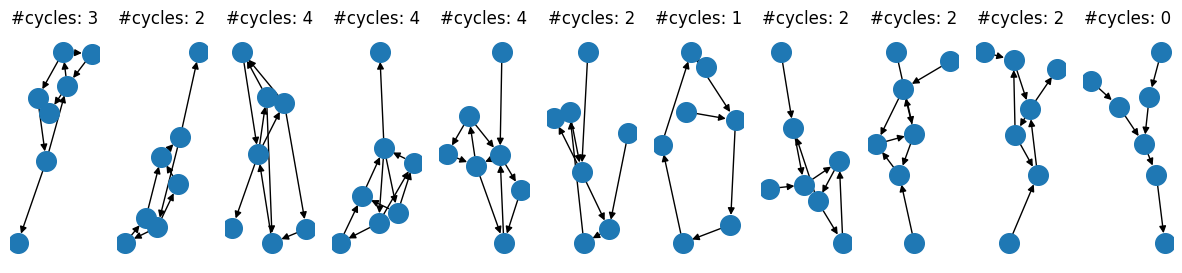

In [82]:
import networkx as nx
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15,3))
for i, graph in enumerate(states):
    ax = fig.add_subplot(1, len(states), i+1)
    graph[graph <= 0] = 0
    gr = nx.from_numpy_array(graph, create_using=nx.MultiDiGraph())
    nx.draw(gr, node_size = 200)
    ax.set_title(f"#cycles: {len([*nx.cycles.simple_cycles(gr)])}")

plt.savefig("RL_walk.png")